In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [3]:
# Initialize an empty list to store the data
labeled_issues_list = []

for i in range(1, 5):  
    with open(f'../labeled-issues/prelabeled_issues_{i}.json') as f:
        labeled_issues = json.load(f)
        labeled_issues_list.extend(list(labeled_issues.values())) 

In [4]:
df = pd.DataFrame(labeled_issues_list)
df["created_at"] = pd.to_datetime(df["created_at"])

In [5]:
df.shape

(400, 8)

In [6]:
trends = df.groupby([df["created_at"].dt.to_period("M"), "predicted_label"]).size().unstack()
trends = trends.loc["2022-01":"2025-12"]
trends = trends.fillna(0)

C:\Users\Myself\AppData\Local\Temp\ipykernel_21228\452145887.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  trends = df.groupby([df["created_at"].dt.to_period("M"), "predicted_label"]).size().unstack()


In [7]:
trends.shape

(36, 15)

19:50:07 - cmdstanpy - INFO - Chain [1] start processing
19:50:07 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Myself\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
C:\Users\Myself\AppData\Local\Temp\ipykernel_21228\2941499718.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(data['ds'], data['y'], 'ko', markersize=4, label='Actual Data', color='red')


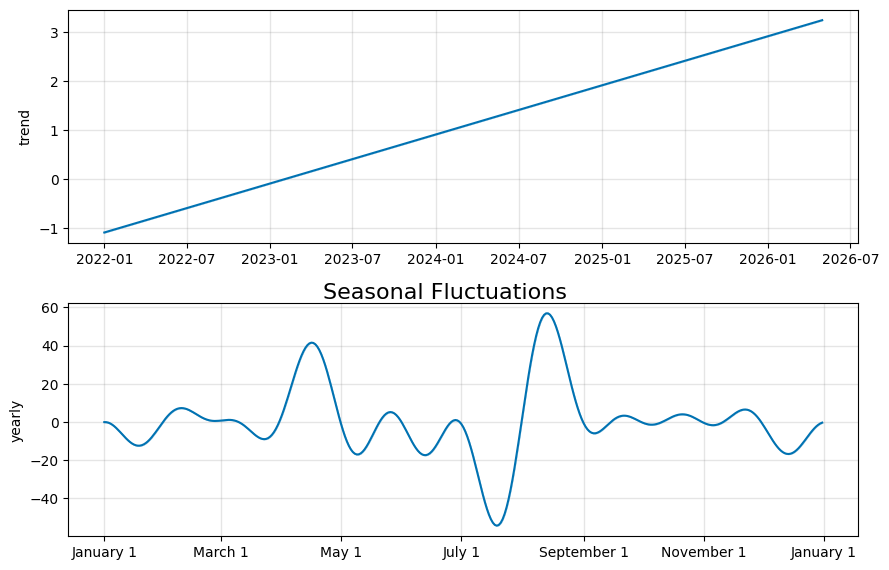

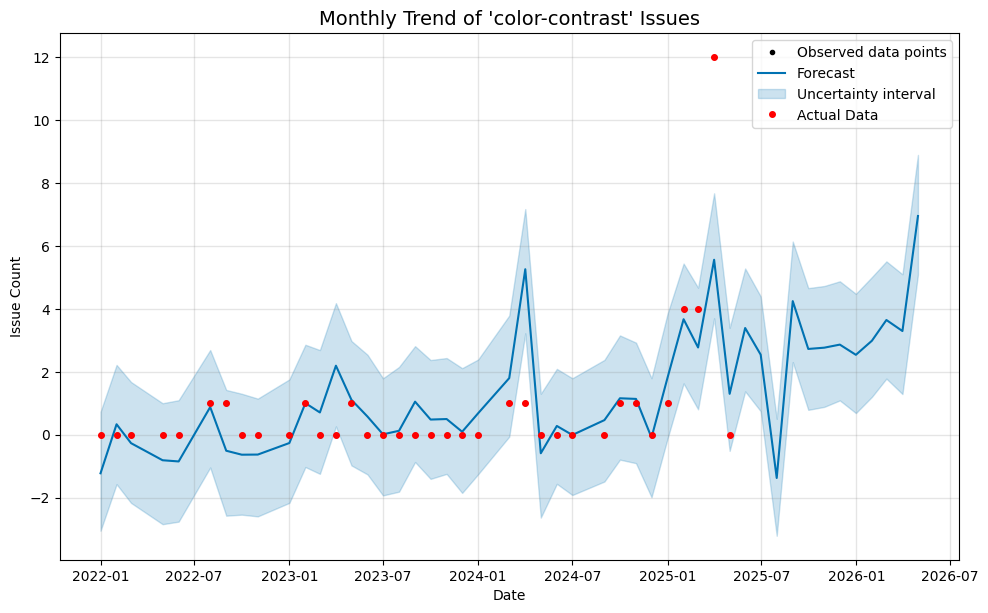

19:50:08 - cmdstanpy - INFO - Chain [1] start processing


Trend significance: p=0.020
Kendall's tau: 0.316


19:50:08 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Myself\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
C:\Users\Myself\AppData\Local\Temp\ipykernel_21228\2941499718.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(data['ds'], data['y'], 'ko', markersize=4, label='Actual Data', color='red')


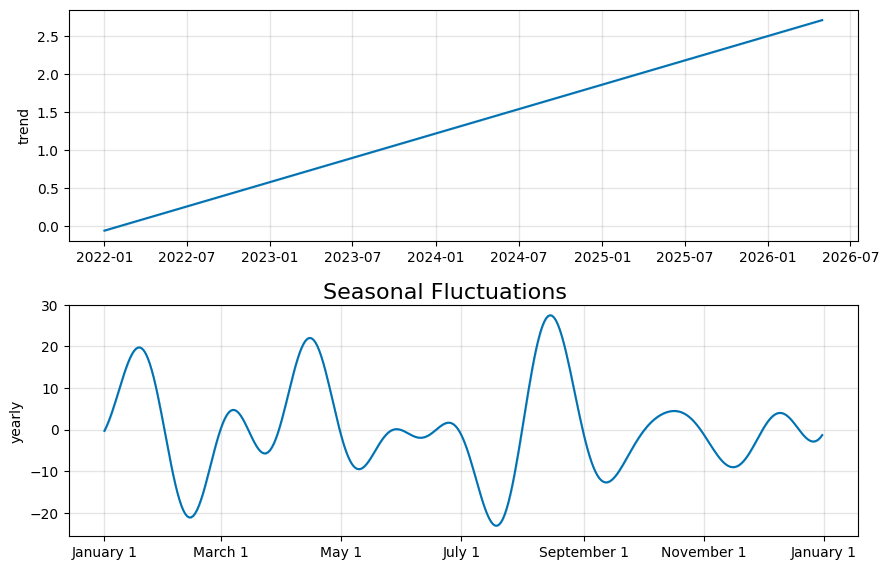

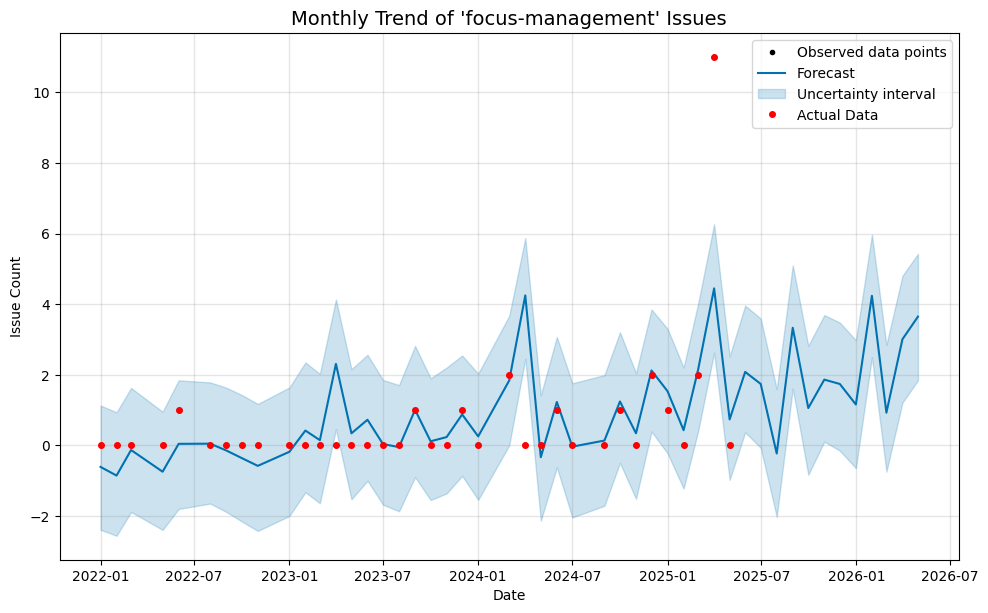

19:50:09 - cmdstanpy - INFO - Chain [1] start processing


Trend significance: p=0.006
Kendall's tau: 0.369


19:50:09 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Myself\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
C:\Users\Myself\AppData\Local\Temp\ipykernel_21228\2941499718.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(data['ds'], data['y'], 'ko', markersize=4, label='Actual Data', color='red')


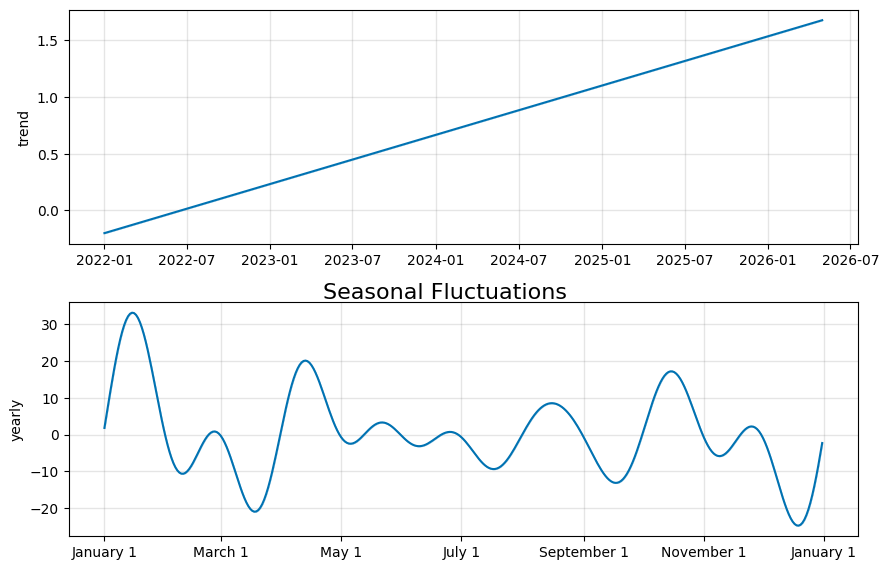

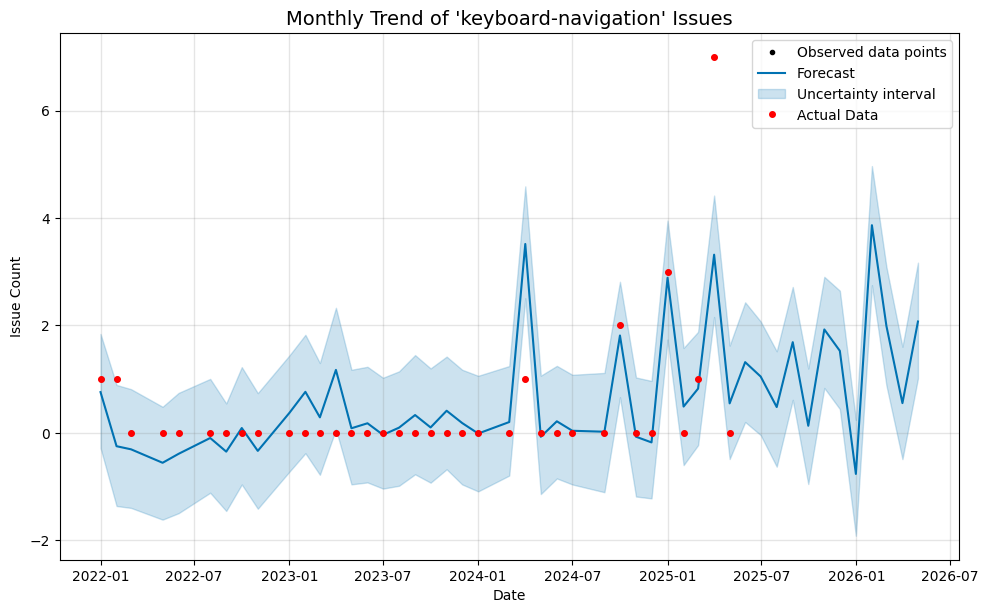

19:50:10 - cmdstanpy - INFO - Chain [1] start processing


Trend significance: p=0.190
Kendall's tau: 0.178


19:50:10 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Myself\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
C:\Users\Myself\AppData\Local\Temp\ipykernel_21228\2941499718.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(data['ds'], data['y'], 'ko', markersize=4, label='Actual Data', color='red')


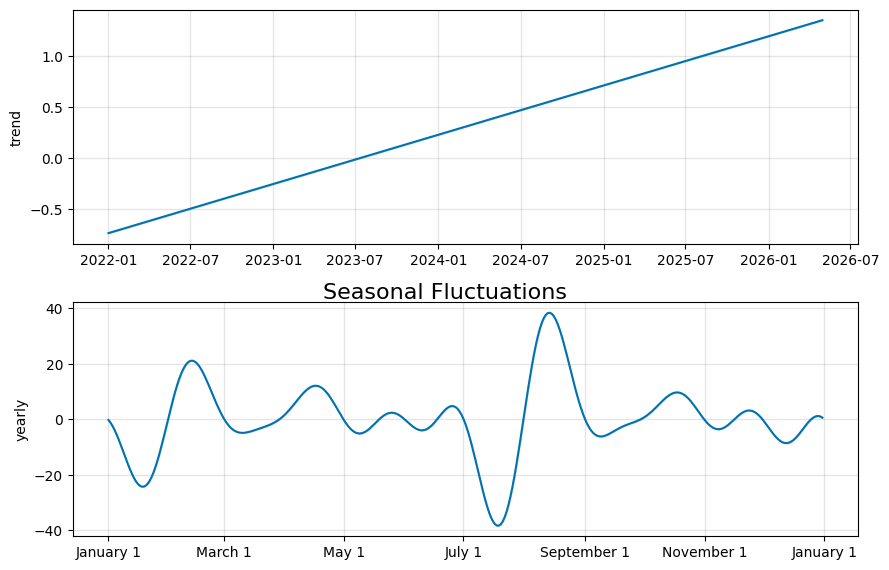

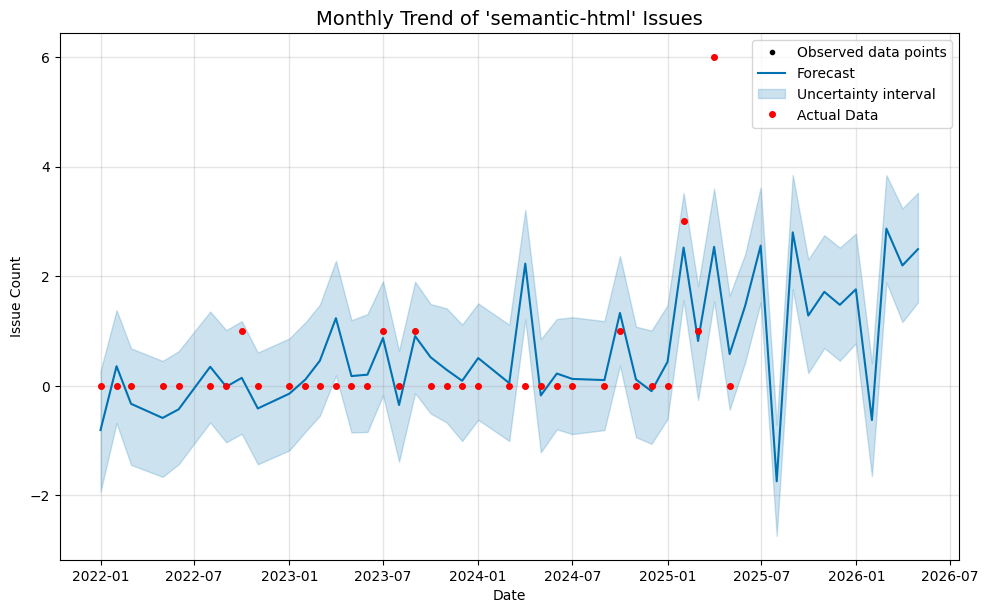

Trend significance: p=0.056
Kendall's tau: 0.261
Average p-value: 0.068
Average Kendall's tau: 0.281


In [34]:
from scipy.stats import kendalltau
from prophet.plot import plot_components

p_values = []
tau_values = []

for label in ["color-contrast", "focus-management", "keyboard-navigation", "semantic-html"]:
  
    # Prepare data for prophet
    data = trends[label].reset_index()
    data["created_at"] = data["created_at"].dt.to_timestamp()
    data = data.rename(columns={"created_at": "ds", label: "y"})
    
    model = Prophet(yearly_seasonality=True).fit(data)
    
    future = model.make_future_dataframe(periods=12, freq="M")
    forecast = model.predict(future)
    
    # plotting seasonality
    plot = plot_components(model, forecast)
    plot.suptitle("Seasonal Fluctuations", fontsize=16, y=0.52)
    for ax in plot.axes:
        ax.set_xlabel("")
    
    
    fig = model.plot(forecast)
    ax = fig.gca()
    ax.set_title(f"Monthly Trend of '{label}' Issues", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Issue Count")
    
    # Plot actual data - use the SAME column names as Prophet expects
    ax.plot(data['ds'], data['y'], 'ko', markersize=4, label='Actual Data', color='red') 
    ax.legend()
    # ax.set_ylim(bottom=0)
    
    plt.show()
    
    tau, p_value = kendalltau(data['ds'].astype('int64'), data['y'])
    print(f"Trend significance: p={p_value:.3f}")
    print(f"Kendall's tau: {tau:.3f}")
    p_values.append(p_value)
    tau_values.append(tau)
    
average_p_value = sum(p_values) / len(p_values)
average_tau_value = sum(tau_values) / len(tau_values)
print(f"Average p-value: {average_p_value:.3f}")
print(f"Average Kendall's tau: {average_tau_value:.3f}")
    